# Классификация цветов автомобилей на DVM-CAR


## 1. Данные и постановка эксперимента

Использован официальный **DVM-CAR 2.0 Confirmed front-view subset**: 61 827 вручную проверенных фронтальных изображений.

Из имени файла извлекаются цвет и `Adv_ID`. Служебная метка `Unlisted` (1 516 изображений) исключена.

Изображений: 60,311; классов: 16; уникальных объявлений: 54,897


split,test,train,val,total
color,,,,
Beige,60,480,60,600
Black,1432,11453,1432,14317
Blue,851,6809,851,8511
Bronze,33,263,33,329
Brown,91,729,91,911
Gold,22,173,22,217
Green,78,621,78,777
Grey,947,7580,947,9474
Multicolour,20,157,19,196


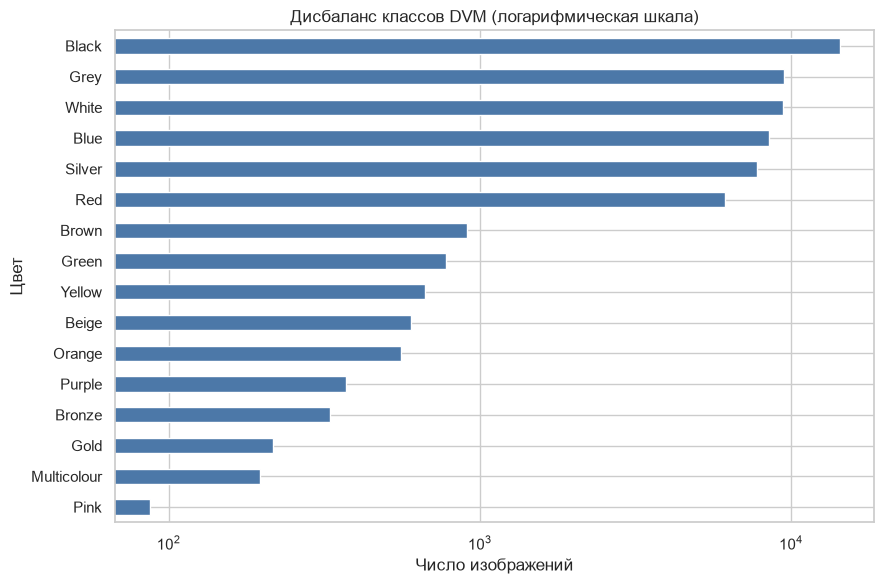

In [2]:
df = pd.read_csv(ART / 'manifest.csv')
classes = json.loads((ART / 'classes.json').read_text(encoding='utf-8'))
summary = (df.groupby(['color','split']).size().unstack(fill_value=0)
             .reindex(classes).assign(total=lambda x: x.sum(axis=1)))
print(f'Изображений: {len(df):,}; классов: {len(classes)}; уникальных объявлений: {df.group.nunique():,}')
display(summary)
ax = summary['total'].sort_values().plot.barh(figsize=(9,6), color='#4c78a8', logx=True)
ax.set(title='Дисбаланс классов DVM (логарифмическая шкала)', xlabel='Число изображений', ylabel='Цвет');
plt.tight_layout(); plt.show()

### Разделение без утечки

Случайный split по файлам завышает качество: одно объявление часто содержит несколько почти одинаковых кадров. Поэтому применён `StratifiedGroupKFold`: все изображения одного `Genmodel_ID + Adv_ID` находятся только в одном split.

In [3]:
from sklearn.model_selection import StratifiedGroupKFold

splitter = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)
fold = np.full(len(df), -1)
for k, (_, idx) in enumerate(splitter.split(df, df.target, groups=df.group)):
    fold[idx] = k
assert np.array_equal(fold, df.fold.to_numpy())
assert not (set(df.loc[df.split=='train','group']) & set(df.loc[df.split=='test','group']))
df.split.value_counts().to_frame('images')

,images
split,
train,48248
test,6032
val,6031


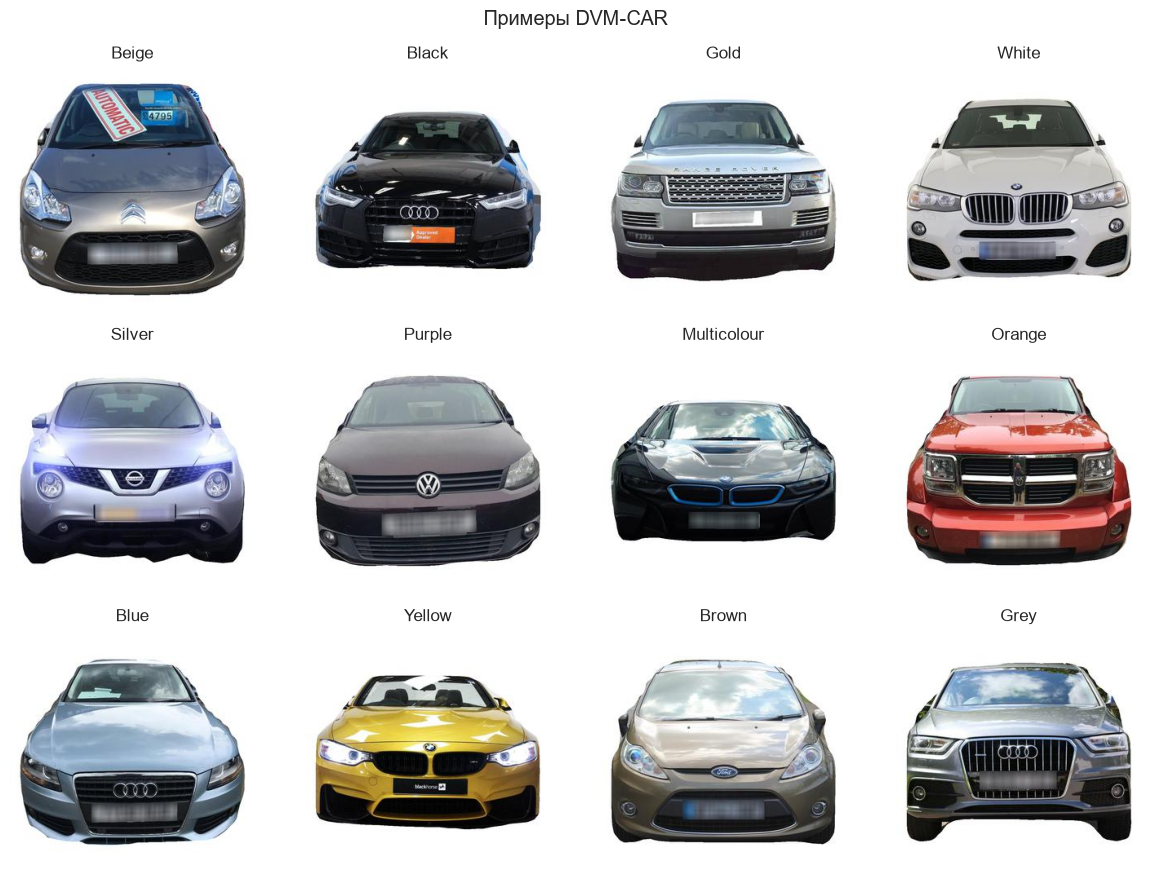

In [4]:
sample = df.groupby('color', group_keys=False).sample(1, random_state=42).sample(frac=1, random_state=42).head(12)
fig, axes = plt.subplots(3,4,figsize=(12,9))
for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    ax.imshow(Image.open(row.path).convert('RGB')); ax.set_title(row.color); ax.axis('off')
plt.suptitle('Примеры DVM-CAR'); plt.tight_layout(); plt.show()

## 2. Предобработка и борьба с дисбалансом

Для train: resize, горизонтальное отражение, слабый affine, умеренные brightness/contrast и очень слабые saturation/hue, затем Random Erasing. Сильный ColorJitter запрещён: он меняет сам целевой признак. Validation/test получают только resize и нормализацию. В loss используются веса $w_c=\sqrt{N/(K n_c)}$ и label smoothing 0.04. Корень смягчает веса: редкие классы важны для macro-F1, но экстремальная обратная частота делала бы обучение нестабильным.

In [5]:
from torchvision import transforms
train_transform = transforms.Compose([
    transforms.Resize((160,160)), transforms.RandomHorizontalFlip(),
    transforms.RandomApply([transforms.RandomAffine(4, translate=(.025,.025), scale=(.94,1.04))], p=.5),
    transforms.ColorJitter(brightness=.12, contrast=.10, saturation=.05, hue=.01),
    transforms.ToTensor(), transforms.Normalize((.485,.456,.406), (.229,.224,.225)),
    transforms.RandomErasing(p=.08, scale=(.02,.08), ratio=(.5,2.0))
])
counts = df[df.split=='train'].target.value_counts().sort_index().to_numpy()
class_weights = np.sqrt(counts.sum() / (len(counts)*counts))
pd.DataFrame({'class':classes, 'n_train':counts, 'loss_weight':class_weights.round(3)})

,class,n_train,loss_weight
0,Beige,480,2.506
1,Black,11453,0.513
2,Blue,6809,0.665
3,Bronze,263,3.386
4,Brown,729,2.034
5,Gold,173,4.175
6,Green,621,2.204
7,Grey,7580,0.631
8,Multicolour,157,4.383
9,Orange,447,2.597


## 3. Три модели: отдельные эксперименты

Одни и те же 16 классов и split: 48 248 train, 6 031 validation, 6 032 test.

Общая схема оптимизации: AdamW (`weight_decay=1e-4`), CrossEntropyLoss с весами
`sqrt(N / (K * n_c))` из train и `label_smoothing=0.04`, ограничение нормы градиента 5.0,
CosineAnnealingLR до `lr/30`, seed 42, FP32 (`use_amp=False`). После каждой эпохи проверяется
validation macro-F1 и сохраняется лучший checkpoint. Число эпох фиксировано: досрочной остановки нет.
Test оценивается после выбора checkpoint. Список конкретных аугментаций приведён в разделе 2.


### 3.1. EfficientNet-B0: перенос признаков ImageNet

**Что взяли за основу.** Готовую CNN `torchvision.models.efficientnet_b0` и веса
`EfficientNet_B0_Weights.IMAGENET1K_V1`, полученные на ImageNet-1K. Готовые признаки адаптируются
к цветам кузова. B0 - компактная базовая версия семейства; в нашем эксперименте её глубина и ширина не меняются.

**Как устроена сеть.** Начальная свёртка выделяет простые локальные признаки. Далее идут MBConv-блоки:
расширение числа каналов свёрткой 1×1, пространственная свёртка отдельно по каналам, SE-внимание и
проекция каналов. Первый MBConv имеет коэффициент расширения 1. Когда размеры совместимы, используется
residual-связь. BatchNorm и SiLU обрабатывают промежуточные признаки. В конце стоит свёртка до 1 280 каналов.

| Часть | Что делает |
|---|---|
| Вход 3×192×192 | RGB-изображение автомобиля |
| `features[0:6]` | Начальная свёртка и ранние MBConv-группы; параметры заморожены |
| `features[6:9]` | Последние две MBConv-группы и завершающая свёртка; параметры дообучаются |
| AdaptiveAvgPool2d(1) | Превращает карты признаков в вектор длины 1 280 |
| Dropout(0.2) → Linear(1280, 16) | Новый классификатор цветов вместо исходных 1 000 классов |

**Как дообучаем.** Используем частичный fine-tuning: ранние параметры имеют `requires_grad=False`,
последние три элемента `features` и новый Linear обучаются.

**Предобработка и обучение.** Resize до 192×192; RGB-нормализация с mean `(0.485, 0.456, 0.406)`
и std `(0.229, 0.224, 0.225)`. В train добавлены отражение, слабый affine/ColorJitter и Random Erasing.
5 эпох, batch 80 (validation/test 160), начальный lr 0.0004. Применяются общие weighted loss,
label smoothing, AdamW и cosine decay, описанные выше. Dropout и сохранённый в backbone stochastic depth
дополняют регуляризацию.

```python
imagenet_norm = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
if name == "efficientnet_imagenet":
        model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
        for p in model.features.parameters(): p.requires_grad = False
        for block in list(model.features.children())[-3:]:
            for p in block.parameters(): p.requires_grad = True
        return model, 192, *imagenet_norm, 80, 5, 4e-4
```

**Результат этой модели.** Лучшая эпоха по validation - 5, validation F1_macro - 0.7332. На test: F1_macro **0.7100**, accuracy **0.8899**.

,epoch,train_loss,val_f1_macro,seconds
0,1,1.4802,0.6563,246.5079
1,2,1.2034,0.6779,172.3872
2,3,1.0782,0.7119,165.8814
3,4,0.9863,0.7268,154.6551
4,5,0.9242,0.7332,153.0190


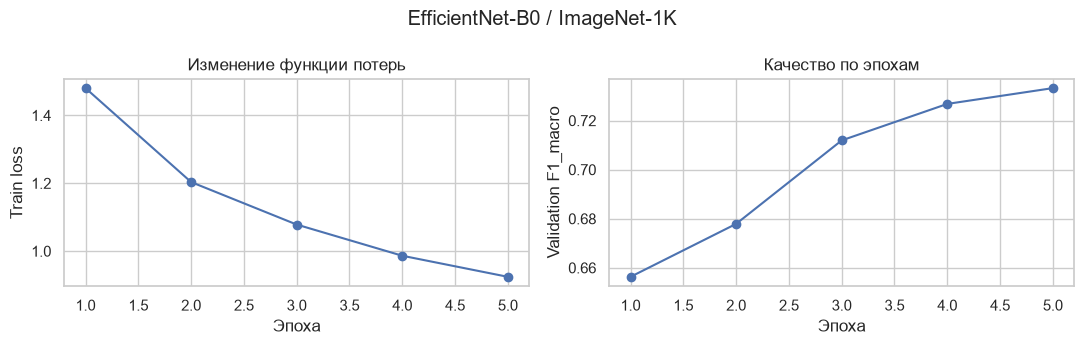

In [6]:
model_result = json.loads((ART / 'efficientnet_imagenet' / 'metrics.json').read_text(encoding='utf-8'))
model_history = pd.DataFrame(model_result['history'])
display(model_history.round(4))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(model_history.epoch, model_history.train_loss, marker='o')
axes[0].set(xlabel='Эпоха', ylabel='Train loss', title='Изменение функции потерь')
axes[1].plot(model_history.epoch, model_history.val_f1_macro, marker='o')
axes[1].set(xlabel='Эпоха', ylabel='Validation F1_macro', title='Качество по эпохам')
fig.suptitle(LABELS['efficientnet_imagenet']); plt.tight_layout(); plt.show()

### 3.2. CLIP ViT-B/32: перенос признаков LAION-400M

**Что взяли за основу.** Модель OpenCLIP `ViT-B-32-quickgelu` с checkpoint `laion400m_e32`.
Она предобучена на парах «изображение - текст» LAION-400M. При таком предобучении визуальный и текстовый
энкодеры учатся сближать представления соответствующих друг другу изображений и описаний.
Это второй источник предобучения, отличный от ImageNet.

**Как устроена сеть.** Визуальная часть - Vision Transformer. Изображение 224×224 делится на
7×7 = 49 патчей размером 32×32. Каждый патч кодируется в вектор длины 768; добавляются позиционные
представления и class token. Последовательность из 50 токенов проходит 12 transformer-блоков:
self-attention связывает разные участки изображения, MLP с QuickGELU преобразует признаки,
LayerNorm и residual-связи помогают обучению. Итоговый вектор class token нормализуется `ln_post`
и проецируется из 768 в 512 измерений.

| Часть | Что делает |
|---|---|
| RGB 3×224×224 → 49 патчей | Подготавливает последовательность токенов |
| 12 visual transformer-блоков | Формируют признаки с учётом разных частей машины |
| `ln_post` и `proj` | Формируют визуальный вектор длины 512 |
| LayerNorm(512) → Dropout(0.15) → Linear(512, 16) | Наш новый классификатор цветов |

**Как дообучаем.** Сначала замораживаем все параметры CLIP. Затем разрешаем обучение последнего
visual transformer-блока, `ln_post`, матрицы `proj` и нового классификатора. Текстовый энкодер остаётся внутри объекта CLIP, но заморожен и при классификации
не вызывается: `forward` использует только `encode_image(..., normalize=False)` и наш head.
Это supervised fine-tuning на метках DVM; текстовые prompts и zero-shot классификация здесь не используются.

**Предобработка и обучение.** Resize до 224×224; mean `(0.48145466, 0.4578275, 0.40821073)`
и std `(0.26862954, 0.26130258, 0.27577711)` соответствуют CLIP. Готовые transform-объекты,
возвращаемые OpenCLIP, в эксперименте не используются: применён общий `make_transforms` с этим размером
и нормализацией. 3 эпохи, batch 64 (validation/test 128), lr 0.00003. Остальные методы —
weighted CrossEntropyLoss, label smoothing 0.04, AdamW, cosine decay, gradient clipping и общие аугментации.


```python
imagenet_norm = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
if name == "clip_laion":
        import open_clip
        clip, _, _ = open_clip.create_model_and_transforms("ViT-B-32-quickgelu", pretrained="laion400m_e32")
        for p in clip.parameters(): p.requires_grad = False
        for module in (clip.visual.transformer.resblocks[-1], clip.visual.ln_post):
            for p in module.parameters(): p.requires_grad = True
        if isinstance(clip.visual.proj, nn.Parameter): clip.visual.proj.requires_grad = True
        model = ClipClassifier(clip, clip.visual.output_dim, num_classes)
        return model, 224, (0.48145466, 0.4578275, 0.40821073), (0.26862954, 0.26130258, 0.27577711), 64, 3, 3e-5

class ClipClassifier(nn.Module):
    def __init__(self, clip_model, feature_dim: int, num_classes: int):
        super().__init__(); self.clip = clip_model
        self.head = nn.Sequential(nn.LayerNorm(feature_dim), nn.Dropout(.15), nn.Linear(feature_dim, num_classes))

    #CLIP формирует визуальный вектор, который новый head переводит в логиты цветов.
    def forward(self, x): return self.head(self.clip.encode_image(x, normalize=False))
```

**Результат этой модели.** Лучшая эпоха по validation - 3, validation F1_macro - 0.7133. На test: F1_macro **0.6994**, accuracy **0.8690**.

,epoch,train_loss,val_f1_macro,seconds
0,1,1.4500,0.6974,468.5503
1,2,1.1814,0.7044,515.4480
2,3,1.0817,0.7133,664.3145


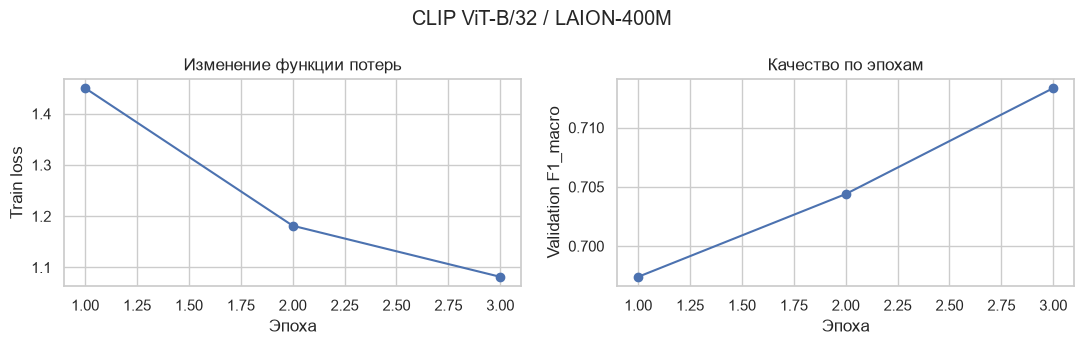

In [7]:
model_result = json.loads((ART / 'clip_laion' / 'metrics.json').read_text(encoding='utf-8'))
model_history = pd.DataFrame(model_result['history'])
display(model_history.round(4))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(model_history.epoch, model_history.train_loss, marker='o')
axes[0].set(xlabel='Эпоха', ylabel='Train loss', title='Изменение функции потерь')
axes[1].plot(model_history.epoch, model_history.val_f1_macro, marker='o')
axes[1].set(xlabel='Эпоха', ylabel='Validation F1_macro', title='Качество по эпохам')
fig.suptitle(LABELS['clip_laion']); plt.tight_layout(); plt.show()

### 3.3. ColorAwareCNN: собственная сеть с нуля

**Что взяли за основу.** Собственную компактную CNN на идеях residual-связей ResNet и поканального
SE-внимания. Готовый ResNet и его веса не загружаются: все параметры инициализируются
случайно и обучаются на DVM. Отличительная часть - дополнительная ветка статистик RGB.

**Как устроена сеть.** Начальная свёртка 5×5 с шагом 2 переводит RGB в 32 карты признаков.
Затем следуют четыре стадии по два `ResidualSEBlock`: первый уменьшает пространственный размер
вдвое и меняет число каналов, второй сохраняет размеры. Всего восемь residual-блоков.

| Часть визуальной ветки | Выход без размерности batch |
|---|---|
| Вход | 3×160×160 |
| Conv 5×5, stride 2 → BatchNorm → SiLU | 32×80×80 |
| Стадия 1: 32→48, два residual-блока | 48×40×40 |
| Стадия 2: 48→80, два residual-блока | 80×20×20 |
| Стадия 3: 80→128, два residual-блока | 128×10×10 |
| Стадия 4: 128→192, два residual-блока | 192×5×5 |
| Global Average Pooling | Вектор из 192 признаков |

Внутри residual-блока идут Conv 3×3 -> BatchNorm -> SiLU -> Conv 3×3 -> BatchNorm -> SE.
SE усредняет карты по пространству, сжимает каналы до `max(8, channels//8)`, затем через SiLU,
обратную проекцию и Sigmoid вычисляет веса каналов. Результат складывается со skip-веткой и проходит SiLU.
При смене размера skip-ветка использует Conv 1×1 с соответствующим шагом и BatchNorm.

**Зачем нужна цветовая ветка.** Из нормализованного входа считаются среднее и стандартное отклонение
каждого из трёх RGB-каналов: всего шесть чисел. Ветка Linear(6, 32) -> BatchNorm1d → SiLU → Dropout(0.1)
превращает их в 32 признака. Они объединяются с 192 CNN-признаками в вектор длины 224.
Dropout(0.3) -> Linear(224, 16) выдаёт итоговые логиты.
Статистики считаются по всему изображению, включая оставшийся после удаления фона фон:
отдельной маски кузова или цветовой гистограммы в модели нет.

**Как обучаем.** Все слои обучаются с нуля. Resize 160×160, batch 72 (validation/test 144),
10 эпох, lr 0.0008. Используем mean/std ImageNet как фиксированную RGB-нормализацию;
это не означает использования ImageNet-весов. Применены BatchNorm, Dropout, weight decay 0.0001,
label smoothing 0.04 и общие аугментации. Взвешенная loss учитывает редкие цвета,
cosine decay уменьшает learning rate, gradient clipping ограничивает большие градиенты.
Лучшие веса выбираются по validation F1_macro.

**Почему такая архитектура.** Остаточные связи облегчают обучение, SE позволяет менять важность
каналов, GAP ограничивает размер классификатора, а RGB-ветка передаёт глобальную информацию о цвете.
Это обоснование проектного выбора: отдельный эксперимент с отключённой RGB-веткой или SE не проводился,
поэтому вклад каждого компонента по полученным метрикам изолированно установить нельзя.

```python
class SE(nn.Module):
    def __init__(self, channels: int, reduction: int = 8):
        super().__init__(); hidden = max(8, channels // reduction)
        self.net = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Conv2d(channels, hidden, 1), nn.SiLU(), nn.Conv2d(hidden, channels, 1), nn.Sigmoid())

    #комментарий Карта признаков умножается на обученные поканальные коэффициенты внимания.
    def forward(self, x): return x * self.net(x)

class ResidualSEBlock(nn.Module):
    def __init__(self, inp: int, out: int, stride: int = 1):
        super().__init__()
        self.body = nn.Sequential(nn.Conv2d(inp, out, 3, stride, 1, bias=False), nn.BatchNorm2d(out), nn.SiLU(), nn.Conv2d(out, out, 3, 1, 1, bias=False), nn.BatchNorm2d(out), SE(out))
        self.skip = (nn.Identity() if inp == out and stride == 1 else nn.Sequential(nn.Conv2d(inp, out, 1, stride, bias=False), nn.BatchNorm2d(out)))
        self.act = nn.SiLU()

    #комментарий Результат свёрточной ветки складывается с исходным или проецированным входом.
    def forward(self, x): return self.act(self.body(x) + self.skip(x))

class ColorAwareCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__(); widths = [32, 48, 80, 128, 192]
        self.stem = nn.Sequential(nn.Conv2d(3, widths[0], 5, 2, 2, bias=False), nn.BatchNorm2d(widths[0]), nn.SiLU())
        blocks = [block for a, b in zip(widths, widths[1:]) for block in (ResidualSEBlock(a, b, 2), ResidualSEBlock(b, b))]
        self.features, self.pool = nn.Sequential(*blocks), nn.AdaptiveAvgPool2d(1)
        self.color_mlp = nn.Sequential(nn.Linear(6, 32), nn.BatchNorm1d(32), nn.SiLU(), nn.Dropout(.1))
        self.classifier = nn.Sequential(nn.Dropout(.3), nn.Linear(widths[-1] + 32, num_classes))

    #комментарий CNN-вектор объединяется со средним и стандартным отклонением RGB, затем классифицируется.
    def forward(self, x):
        visual = self.pool(self.features(self.stem(x))).flatten(1)
        color = self.color_mlp(torch.cat([x.mean((2, 3)), x.std((2, 3))], 1))
        return self.classifier(torch.cat([visual, color], 1))
```

**Результат этой модели.** Лучшая эпоха по validation - 10, validation F1_macro - 0.6789. На test: F1_macro **0.6632**, accuracy **0.8707**.

,epoch,train_loss,val_f1_macro,seconds
0,1,1.8274,0.3880,172.9531
1,2,1.5542,0.4978,121.2564
2,3,1.4396,0.5519,124.4843
3,4,1.3619,0.5603,125.8913
4,5,1.3006,0.6128,125.4264
5,6,1.2370,0.6068,132.2980
6,7,1.1816,0.6422,124.0464
7,8,1.1254,0.6509,115.8184
8,9,1.0797,0.6701,126.5619
9,10,1.0505,0.6789,119.5469


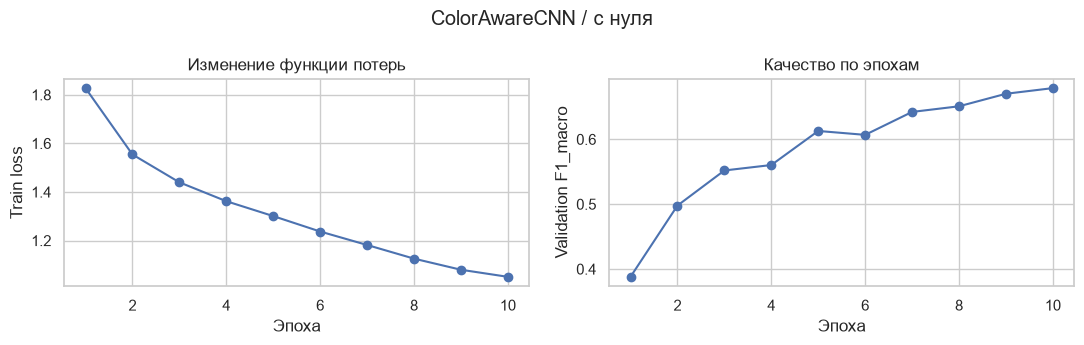

In [8]:
model_result = json.loads((ART / 'scratch' / 'metrics.json').read_text(encoding='utf-8'))
model_history = pd.DataFrame(model_result['history'])
display(model_history.round(4))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(model_history.epoch, model_history.train_loss, marker='o')
axes[0].set(xlabel='Эпоха', ylabel='Train loss', title='Изменение функции потерь')
axes[1].plot(model_history.epoch, model_history.val_f1_macro, marker='o')
axes[1].set(xlabel='Эпоха', ylabel='Validation F1_macro', title='Качество по эпохам')
fig.suptitle(LABELS['scratch']); plt.tight_layout(); plt.show()

## 4. Метрика F1_macro

Для каждого класса вычисляется $F1_c=2\,precision_c\,recall_c/(precision_c+recall_c)$, затем $F1_{macro}=\frac1K\sum_c F1_c$. Каждый цвет имеет одинаковый вес независимо от частоты. Поэтому метрика подходит для несбалансированного DVM и отвечает на вопрос «насколько хорошо модель работает в среднем по цветам». При этом одно число не показывает, какие именно классы провалены; его обязательно читать вместе с per-class F1 и confusion matrix.

In [10]:
metrics = {n: json.loads((ART/n/'metrics.json').read_text(encoding='utf-8')) for n in MODEL_NAMES}
results = pd.DataFrame([{
    'model': LABELS[n], 'F1_macro': metrics[n]['f1_macro'],
    'accuracy': metrics[n]['accuracy'], 'test_size': metrics[n]['n_test'],
    'best_val_F1': max(h['val_f1_macro'] for h in metrics[n]['history'])
} for n in MODEL_NAMES]).sort_values('F1_macro', ascending=False)
display(results.style.format({'F1_macro':'{:.4f}','accuracy':'{:.4f}','best_val_F1':'{:.4f}'}))

,model,F1_macro,accuracy,test_size,best_val_F1
0,EfficientNet-B0 / ImageNet-1K,0.7100,0.8899,6032,0.7332
1,CLIP ViT-B/32 / LAION-400M,0.6994,0.8690,6032,0.7133
2,ColorAwareCNN / с нуля,0.6632,0.8707,6032,0.6789


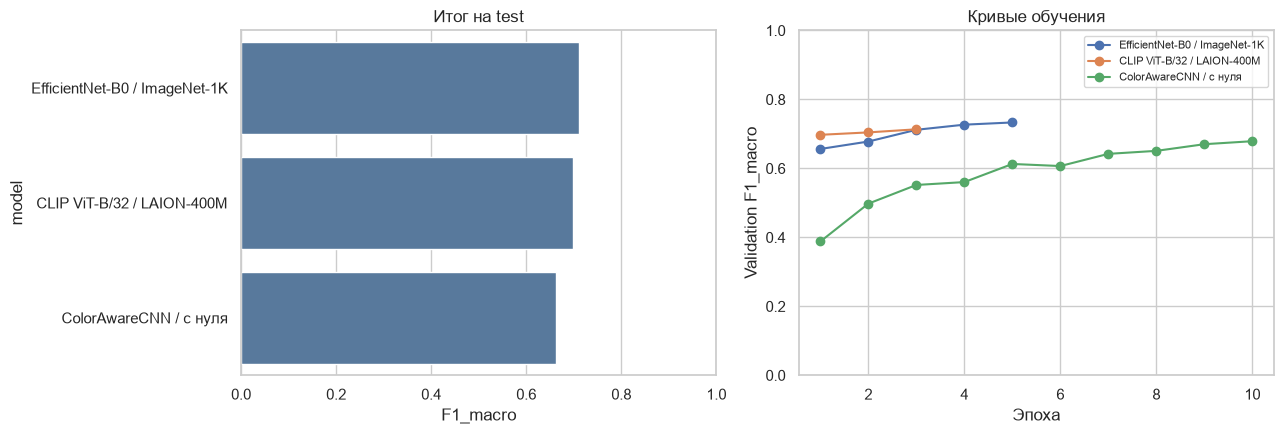

In [11]:
fig, axes = plt.subplots(1,2,figsize=(13,4.5))
sns.barplot(data=results, x='F1_macro', y='model', ax=axes[0], color='#4c78a8')
axes[0].set_xlim(0,1); axes[0].set_title('Итог на test')
for n in MODEL_NAMES:
    h = pd.DataFrame(metrics[n]['history'])
    axes[1].plot(h.epoch, h.val_f1_macro, marker='o', label=LABELS[n])
axes[1].set(xlabel='Эпоха', ylabel='Validation F1_macro', ylim=(0,1), title='Кривые обучения')
axes[1].legend(fontsize=8); plt.tight_layout(); plt.show()

,EfficientNet-B0 / ImageNet-1K,CLIP ViT-B/32 / LAION-400M,ColorAwareCNN / с нуля
Beige,0.746,0.677,0.565
Black,0.913,0.887,0.900
Blue,0.905,0.865,0.886
Bronze,0.400,0.375,0.349
Brown,0.607,0.581,0.505
Gold,0.409,0.255,0.458
Green,0.859,0.824,0.772
Grey,0.814,0.804,0.801
Multicolour,0.167,0.258,0.000
Orange,0.783,0.790,0.738


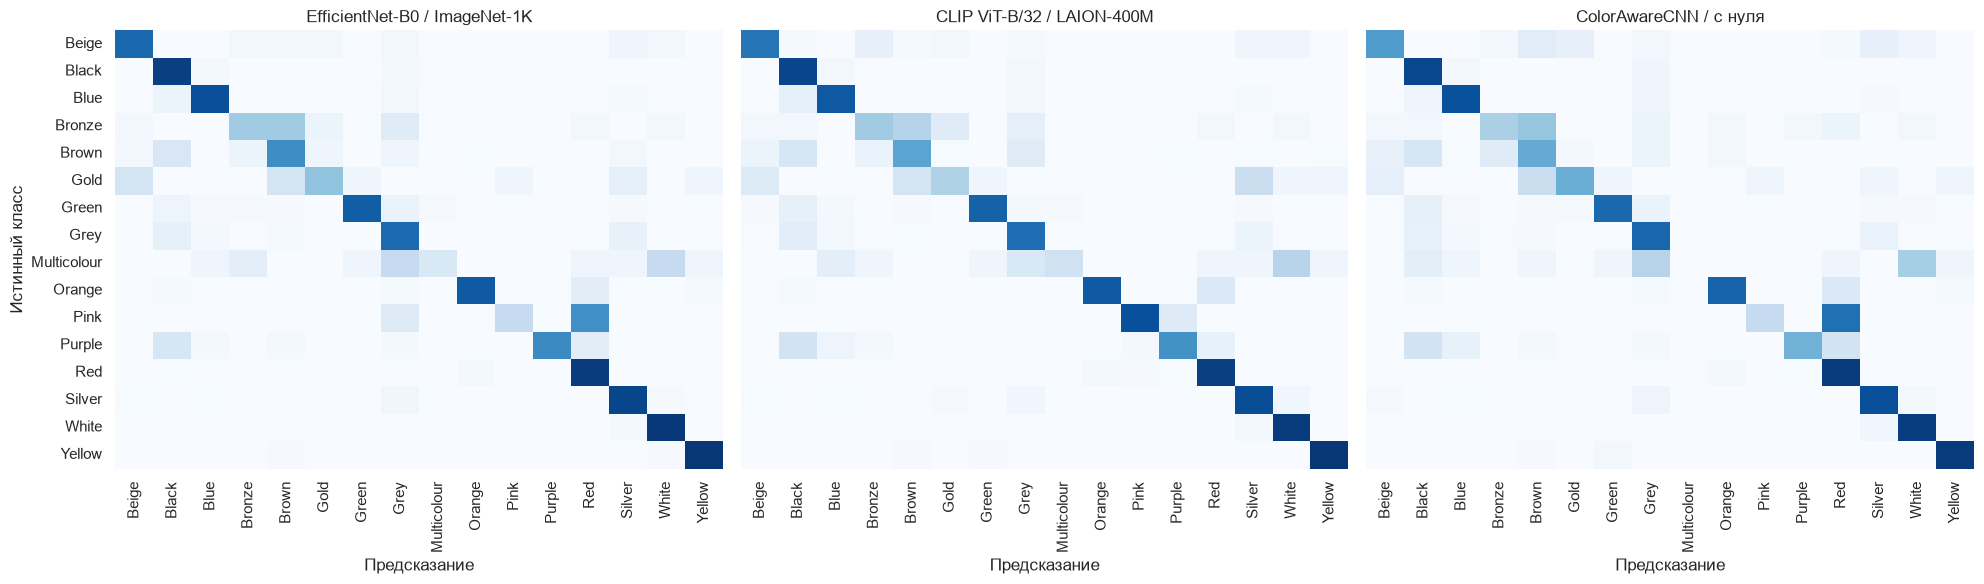

In [12]:
per_class = pd.DataFrame({LABELS[n]: {c: metrics[n]['classification_report'][c]['f1-score'] for c in classes}
                          for n in MODEL_NAMES}).reindex(classes)
display(per_class.style.format('{:.3f}').background_gradient(cmap='YlGn', vmin=0, vmax=1))
fig, axes = plt.subplots(1,3,figsize=(20,6), sharex=True, sharey=True)
for ax, n in zip(axes, MODEL_NAMES):
    cm = np.load(ART/n/'confusion_matrix.npy')
    sns.heatmap(cm, ax=ax, cmap='Blues', vmin=0, vmax=1, xticklabels=classes, yticklabels=classes, cbar=False)
    ax.set_title(LABELS[n]); ax.set_xlabel('Предсказание'); ax.tick_params(axis='x', rotation=90)
axes[0].set_ylabel('Истинный класс'); plt.tight_layout(); plt.show()

## 5. Примеры предсказаний

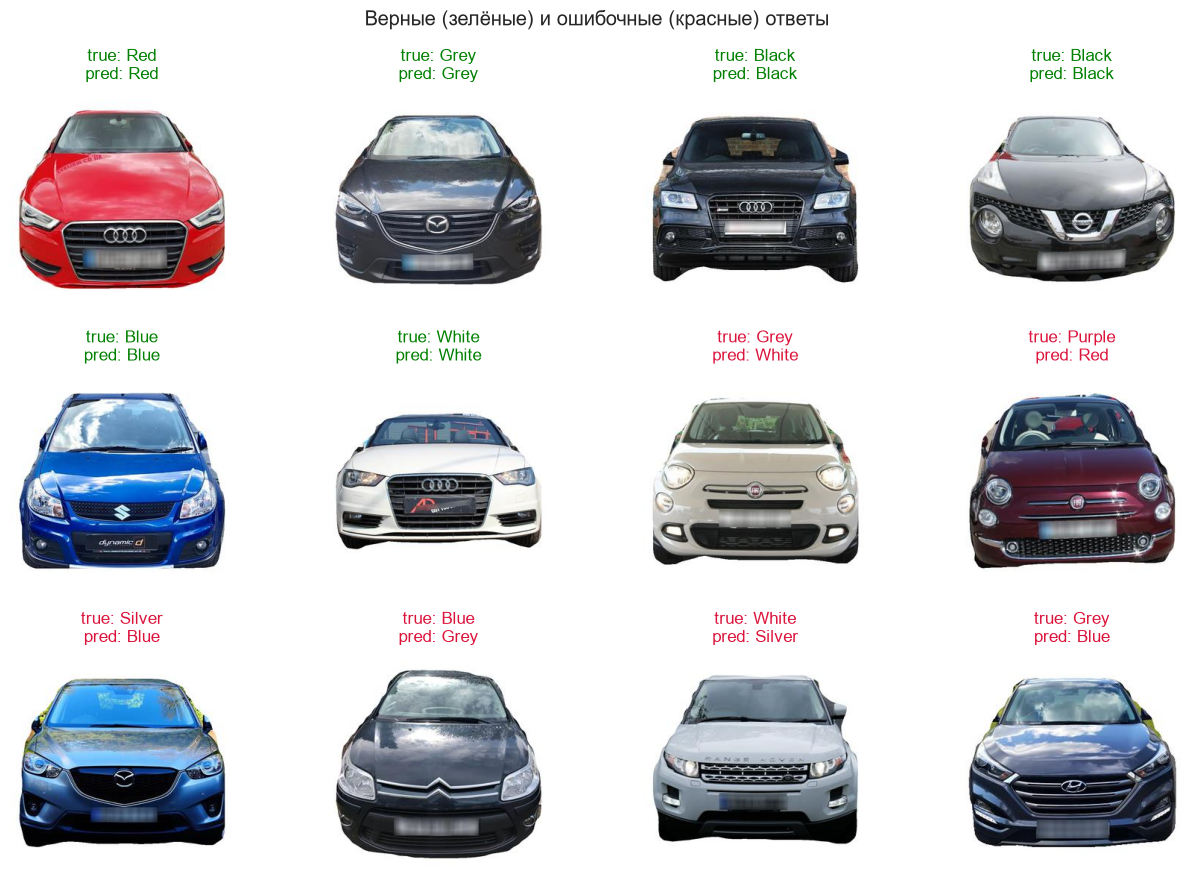

In [13]:
best_name = 'efficientnet_imagenet'
pred = pd.read_csv(ART/best_name/'predictions.csv')
pred['true'] = pred.y_true.map(dict(enumerate(classes)))
pred['pred'] = pred.y_pred.map(dict(enumerate(classes)))
ok = pred[pred.y_true==pred.y_pred].sample(6, random_state=42)
err = pred[pred.y_true!=pred.y_pred].sample(min(6, (pred.y_true!=pred.y_pred).sum()), random_state=42)
examples = pd.concat([ok,err])
fig, axes = plt.subplots(3,4,figsize=(13,9))
for ax in axes.flat: ax.axis('off')
for ax, (_, r) in zip(axes.flat, examples.iterrows()):
    ax.imshow(Image.open(r.path).convert('RGB')); ax.axis('off')
    ax.set_title(f"true: {r['true']}\npred: {r['pred']}", color=('green' if r.y_true==r.y_pred else 'crimson'))
plt.suptitle('Верные (зелёные) и ошибочные (красные) ответы'); plt.tight_layout(); plt.show()

## 6. Выводы

1. Лучший test-результат показал **EfficientNet-B0 / ImageNet-1K: F1_macro = 0.7100**. Отрыв от второго места (CLIP ViT-B/32 / LAION-400M) - 0.0106.
2. ImageNet-модель получила 0.7100, LAION-CLIP - 0.6994, собственная сеть с нуля - 0.6632. Разница показывает ценность переноса визуальных признаков, но источник предобучения и соответствие домену важнее самого факта pretraining.
3. F1_macro означает средний баланс precision/recall по всем 16 цветам, а не долю правильных ответов. Значение существенно выше случайного baseline (1/16 = 0.0625), однако до 1.0 остаётся запас: редкие и близкие по внешнему виду оттенки (например, Grey/Silver и Bronze/Brown) ограничивают качество.
4. Accuracy выше F1_macro у всех моделей - сигнал дисбаланса: частые Black/White/Grey/Silver распознаются лучше редких цветов. Поэтому заменять macro-F1 одной accuracy нельзя.
5. Оценка консервативна: group split запрещает почти дубликатам одного объявления пересекать train/test. Для дальнейшего роста качества полезны иерархическая классификация близких оттенков, targeted augmentation редких классов, более крупный backbone и проверка на отдельном датасете/реальных фотографиях с фоном.